In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, BaseSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import awkward as ak

In [2]:
samples = [
    "2Mu2E_200GeV_5p0GeV_0p2mm",
]

In [3]:
fileset = utilities.make_fileset(samples[0:1], 
                                 "llpNanoAOD_v2", 
                                 location_cfg="signal_2mu2e_v10.yaml",
                                 max_files = 1,
                                )

In [4]:
runner = processor.Runner(
    # executor=processor.DaskExecutor(client=client),
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True
)

channels = [
    "baseNoLjNoLjsource", "baseNoLj", "base_ljObjCut", "base",
]

p = sidm_processor.SidmProcessor(
    channels,
    ["muon_base", "dsaMuon_base", "lj_lj_base"],
    unweighted_hist=True,
    save_intermediate=True,
)

out = {}
for i, sample in enumerate(samples):

    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)

    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

    ##Save output to a file!!
    out_file_name = "output_" + sample + ".coffea"
    # coffea.util.save(output,out_file_name) 

Output()

Processing 2Mu2E_200GeV_5p0GeV_0p2mm


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

#--------------------------------------------------------------------------
#                         FastJet release 3.4.3
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Signal not in xs cfg, assuming 1fb


In [5]:
out[samples[0]].keys()

dict_keys(['cutflow', 'hists', 'counters', 'metadata', 'events'])

In [6]:
out[samples[0]]['events']

{'baseNoLjNoLjsource': {'pvs': <VertexArray [[{ndof: ??, x: ??, y: ??, ...}], ...] type='467 * var * Verte...'>,
  'bs': <NanoCollectionArray [[{x: 0.0108, y: 0.0419, ...}], ...] type='467 * var *...'>,
  'met': <MissingETArray [MissingET, ...] type='467 * MissingET[MetUnclustEnUpDeltaX...'>,
  'hlt': <NanoCollectionArray [{...}, {...}, {...}, ..., {...}, {...}] type='467 * N...'>,
  'electrons': <ElectronArray [[Electron, ...], ...] type='467 * var * Electron[dEscaleDow...'>,
  'photons': <PhotonArray [[Photon, ...], ...] type='467 * var * Photon[dEscaleDown: flo...'>,
  'muons': <LLPMuonArray [[LLPMuon, LLPMuon], ...] type='467 * var * LLPMuon[dxy: floa...'>,
  'dsaMuons': <DSAMuonArray [[DSAMuon, ...], ...] type='467 * var * DSAMuon[idx: float32[...'>,
  'weight': <Array [1, 1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1] type='467 * float32[parameter...'>,
  'gens': <GenParticleArray [[GenParticle, ...], ...] type='467 * var * GenParticle[e...'>,
  'genMus': <GenParticleArray [[GenParticle, ...

In [7]:
out[samples[0]]['events']["base"].keys()

dict_keys(['pvs', 'bs', 'met', 'hlt', 'electrons', 'photons', 'muons', 'dsaMuons', 'weight', 'gens', 'genMus', 'genEs', 'genAs', 'genAs_toMu', 'genAs_toE', 'rho_PFIso', 'jets', 'ljs', 'mu_ljs', 'egm_ljs', 'pfmu_ljs', 'dsamu_ljs', 'electron_ljs', 'photon_ljs', 'ch', 'lj_reco', 'weights'])

In [8]:
out[samples[0]]['events']["base"]["ljs"].fields

['x',
 'y',
 'z',
 't',
 'constituents',
 'muons',
 'pfMuons',
 'dsaMuons',
 'electrons',
 'photons',
 'pfMu_n',
 'dsaMu_n',
 'muon_n',
 'electron_n',
 'photon_n',
 'dRSpread',
 'matched_jet',
 'lepton_fraction',
 'isolation',
 'dR_matched_jet']

In [9]:
len(out[samples[0]]['events']["base"]["ljs"])

412

In [10]:
# out = coffea.util.load("path/to/your/output.coffea")

In [11]:
lj_reco_key = str(p.lj_reco_choices[0])

print("--- Starting to save intermediate skims (using .parquet format) ---")

for sample_name in samples:
    if sample_name not in out:
        print(f"Warning: Sample '{sample_name}' not found in output. Skipping.")
        continue

    print(f"\nProcessing sample: {sample_name}")
    
    for channel_name in channels:
        
        skim_filename = f"my_intermediate_skim_{sample_name}_{channel_name}.parquet" # <--- .parquet
        
        try:
            events_data = out[sample_name]['events']
            
            if lj_reco_key in events_data:
                skim_events_to_save = events_data[lj_reco_key][channel_name]
            else:
                skim_events_to_save = events_data[channel_name]

            # 'skim_events_to_save' is a dict of lazy VirtualArrays.
            # We must get the length from one of its fields (which is *also* lazy).
            
            # The lazy object is a dict-like record, so we check .keys() or .fields
            all_keys = list(skim_events_to_save.keys()) 
            if not all_keys:
                 print(f"  -> No data found for channel '{channel_name}'. Skipping.")
                 continue

            n_events_field = all_keys[0]
            n_events = len(skim_events_to_save[n_events_field])

            if n_events > 0:
                # Use ak.to_parquet. This will compute the Dask arrays.
                print(f"  -> Computing and saving {n_events} events...")
                ak.to_parquet(skim_events_to_save, skim_filename)
                print(f"     ... Saved successfully to: {skim_filename}")
            else:
                print(f"  -> No events passed for channel '{channel_name}'. Skipping file save.")

        except KeyError:
            print(f"  -> Warning: No events data found for channel '{channel_name}'. Skipping.")
        except Exception as e:
            print(f"  -> Error processing {sample_name}/{channel_name}: {e}")

print("\n--- All skims saved ---")

--- Starting to save intermediate skims (using .parquet format) ---

Processing sample: 2Mu2E_200GeV_5p0GeV_0p2mm
  -> Computing and saving 467 events...
     ... Saved successfully to: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLjNoLjsource.parquet
  -> Computing and saving 467 events...
     ... Saved successfully to: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLj.parquet
  -> Computing and saving 467 events...
     ... Saved successfully to: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_base_ljObjCut.parquet
  -> Computing and saving 412 events...
     ... Saved successfully to: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_base.parquet

--- All skims saved ---


In [12]:
import awkward as ak
import dask_awkward as dak
print(ak.__version__)
print(dak.__version__)

2.8.2
2025.5.0


In [13]:
importlib.reload(sidm_processor)
# Programmatically build the 'items_to_process' LIST ---
items_to_process = []
print("--- Building items list for skim run ---")
for sample_name in samples:
    for channel_name in channels:
        
        dataset_key = f"skim_{sample_name}_{channel_name}"
        filename = f"my_intermediate_skim_{sample_name}_{channel_name}.parquet"
        
        if os.path.exists(filename):
            print(f"  Loading file: {filename}")
            try:
                # Load the data from the Parquet file
                loaded_data = ak.from_parquet(filename)
                
                # 'loaded_data' is a Record. We must check the length
                # of one of its fields to get the number of events.
                
                if not loaded_data.fields:
                    print(f"    -> Skipping empty file (no fields).")
                    continue # Go to next file

                # Get length from the first field (e.g., 'muons')
                n_events = len(loaded_data[loaded_data.fields[0]])

                if n_events > 0:
                    # Add a (data, dataset_name) tuple to our list
                    items_to_process.append( (loaded_data, dataset_key) )
                    print(f"    -> Added dataset '{dataset_key}' with {n_events} events")
                else:
                    print(f"    -> Skipping empty file (0 events).")
            except Exception as e:
                print(f"    -> ERROR loading {filename}: {e}")
        else:
            pass # This is normal if a sample/channel combo had no events

# Instantiate a processor for SKIM READING ---
p_skim = sidm_processor.SidmProcessor(
    channel_names=channels,
    hist_collection_names=["muon_base", "dsaMuon_base", "lj_lj_base"], 
    read_intermediate=True,
    save_intermediate=False,
)

# Set up and run with IterativeExecutor DIRECTLY ---
print("\nStarting processor run on all skims (via direct executor call)...")

executor_instance = processor.IterativeExecutor()
accumulator = processor.dict_accumulator({})

# Call the executor directly.
(out_skim, _) = executor_instance(
    items=items_to_process,
    function=p_skim.process,  
    accumulator=accumulator
)

print("...Processor run on all skims finished!")

--- Building items list for skim run ---
  Loading file: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLjNoLjsource.parquet
    -> Added dataset 'skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLjNoLjsource' with 467 events
  Loading file: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLj.parquet
    -> Added dataset 'skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLj' with 467 events
  Loading file: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_base_ljObjCut.parquet
    -> Added dataset 'skim_2Mu2E_200GeV_5p0GeV_0p2mm_base_ljObjCut' with 467 events
  Loading file: my_intermediate_skim_2Mu2E_200GeV_5p0GeV_0p2mm_base.parquet


Output()

    -> Added dataset 'skim_2Mu2E_200GeV_5p0GeV_0p2mm_base' with 412 events

Starting processor run on all skims (via direct executor call)...


Note: failed to apply nested selections on skim (this is normal if fields were dropped): '@events_factory'

Warning: Unable to apply event cuts to ch. Skipping.

...

Warning: a histogram with the name muon_numOverlapSegments_matchedDSAMuons could not be filled and will be skipped

Warning: a histogram with the name dsaMuon_numOverlapSegments_matchedMuons could not be filled and will be skipped

Warning: cannot fill counter Matched gen As to muons. Skipping.

Warning: cannot fill counter Matched gen As to electrons. Skipping.

...Processor run on all skims finished!


In [14]:
out_skim

{'skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLjNoLjsource': {'cutflow': {'baseNoLjNoLjsource': <sidm.tools.cutflow.Cutflow at 0x7fb286727320>,
   'baseNoLj': <sidm.tools.cutflow.Cutflow at 0x7fb286a07bc0>,
   'base_ljObjCut': <sidm.tools.cutflow.Cutflow at 0x7fb286b7a210>,
   'base': <sidm.tools.cutflow.Cutflow at 0x7fb2855c0050>},
  'hists': {'muon_n': <sidm.tools.histogram.Histogram at 0x7fb284b5b140>,
   'muon_pt': <sidm.tools.histogram.Histogram at 0x7fb2855c3c50>,
   'muon_dxy': <sidm.tools.histogram.Histogram at 0x7fb2855c1f40>,
   'muon_eta_phi': <sidm.tools.histogram.Histogram at 0x7fb2855c0ec0>,
   'muon_absD0': <sidm.tools.histogram.Histogram at 0x7fb2855c36e0>,
   'muon_absD0_lowRange': <sidm.tools.histogram.Histogram at 0x7fb2855c1d60>,
   'muon_numOverlapSegments_matchedDSAMuons': <sidm.tools.histogram.Histogram at 0x7fb2855c3380>,
   'muon_numOverlapSegments_goodMatchedDSAMuons': <sidm.tools.histogram.Histogram at 0x7fb2855c35f0>,
   'dsaMuon_n': <sidm.tools.histogram.Histogram

In [15]:
import importlib
import sidm.tools.cutflow
importlib.reload(cutflow)

print("--- Inspecting out_skim ---")

# See all the datasets that were processed
all_datasets = list(out_skim.keys())
print(f"Total datasets processed: {len(all_datasets)}")

if not all_datasets:
    print("Error: out_skim is empty! Something went wrong.")
else:
    print(f"First 5 datasets processed: {all_datasets[:5]}")

    # Pick one dataset to inspect
    # We'll pick the first one from the list.
    dataset_to_inspect = all_datasets[0]
    print(f"\n--- Inspecting Dataset: {dataset_to_inspect} ---")
    
    # Get the processor output for this single dataset
    dataset_output = out_skim[dataset_to_inspect]
    print(f"Output keys: {list(dataset_output.keys())}")
    
    # Inspect Metadata
    print("\n--- Metadata ---")
    # Metadata values are value_accumulators, so we access .value
    n_evts = dataset_output['metadata']['n_evts'].value
    sum_w = dataset_output['metadata']['scaled_sum_weights'].value
    print(f"  n_evts (from skim): {n_evts}")
    print(f"  scaled_sum_weights (from skim): {sum_w}")
    
    # Inspect Cutflow
    print("\n--- Cutflow ---")
    cutflow_acc = dataset_output['cutflow']
    
    # The processor ran all channels. Let's find the one that matches
    # our dataset name (e.g., 'base' from 'skim_..._base')
    matching_channel = None
    # 'p_skim' is the processor instance from the cell above
    for ch in p_skim.channel_names: 
        if f"_{ch}" in dataset_to_inspect:
            matching_channel = ch
            break
    
    if matching_channel:
        print(f"Showing cutflow for matching channel: '{matching_channel}'")
        try:
            # The cutflow object is at [channel_key]
            my_cutflow_object = cutflow_acc[matching_channel]
            
            # Call print_table()
            my_cutflow_object.print_table()
        except KeyError:
            print(f"Error: Could not find cutflow for channel '{matching_channel}'")
            print(f"Available cutflow keys: {list(cutflow_acc.keys())}")
    else:
        print(f"Could not find a matching channel to print cutflow for {dataset_to_inspect}.")

    # Inspect Histograms
    print("\n--- Histograms ---")
    hists_acc = dataset_output['hists']
    
    # Let's inspect a histogram (e.g., 'muon_pt')
    hist_name = 'muon_pt'
    if hist_name in hists_acc:
        print(f"\nInspecting histogram: '{hist_name}'")
        # Get the Histogram object
        hist_obj = hists_acc[hist_name]
        
        # Print the underlying hist.Hist object
        print(hist_obj.hist)
        
        # Print the sum of counts for all channels
        print(f"  Total sum (all channels): {hist_obj.hist.sum()}")
        
        # You can also view the data for *just* the matching channel
        if matching_channel:
            print(f"  Data for '{matching_channel}' channel only:")
            # Use hist slicing: H[channel, ...]
            print(hist_obj.hist[matching_channel, :])
    else:
        print(f"Histogram '{hist_name}' not found.")
        print(f"Available hists: {list(hists_acc.keys())[:10]}...")

--- Inspecting out_skim ---
Total datasets processed: 4
First 5 datasets processed: ['skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLjNoLjsource', 'skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLj', 'skim_2Mu2E_200GeV_5p0GeV_0p2mm_base_ljObjCut', 'skim_2Mu2E_200GeV_5p0GeV_0p2mm_base']

--- Inspecting Dataset: skim_2Mu2E_200GeV_5p0GeV_0p2mm_baseNoLjNoLjsource ---
Output keys: ['cutflow', 'hists', 'counters', 'metadata']

--- Metadata ---
  n_evts (from skim): 467
  scaled_sum_weights (from skim): 467.0

--- Cutflow ---
Showing cutflow for matching channel: 'baseNoLjNoLjsource'
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                467.0        467.0
pass triggers               467.0        467.0
PV filter                   467.0        467.0

--- Histograms ---

Inspecting histogram: 'muon_pt'
Hist(
  StrCategory(['baseNoLjNoLjsource', 'baseNoLj', 'base_ljObjCut', 'base'], name='channel', label='Channel'),
  Regular(100, 0, 500, name='muo

In [16]:
out_skim[f'skim_{samples[0]}_{channels[0]}']["hists"]["muon_n"]

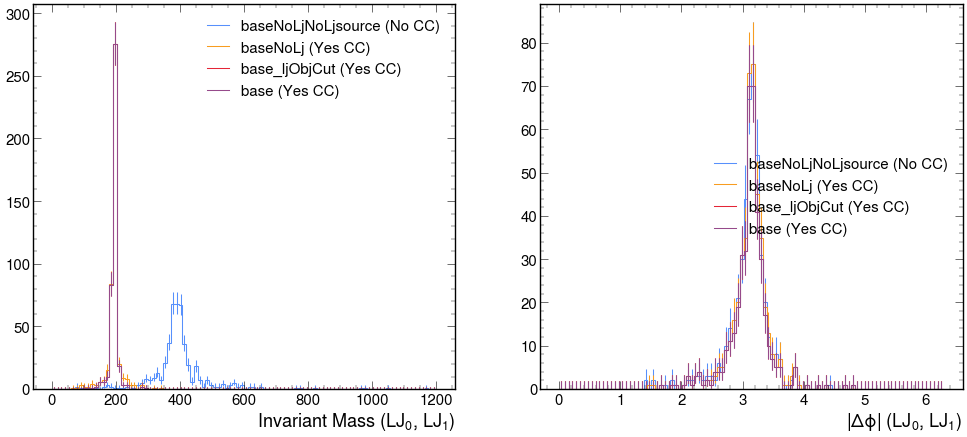

In [17]:
import mplhep as hep

hist_list = []
for ch in channels:
    hist_obj = out_skim[f'skim_{samples[0]}_{ch}']["hists"]["lj_lj_invmass"]
    hist_data = hist_obj.hist
    hist_1d = hist_data[ch, :] 
    hist_list.append(hist_1d)

plt.subplots(1,2,figsize=(24,10))
plt.subplot(1,2,1)

hep.histplot(hist_list) 

plt.legend(["baseNoLjNoLjsource (No CC)", "baseNoLj (Yes CC)", "base_ljObjCut (Yes CC)", "base (Yes CC)"])

hist_list = []
for ch in channels:
    hist_obj = out_skim[f'skim_{samples[0]}_{ch}']["hists"]["lj_lj_absdphi"]   
    hist_data = hist_obj.hist
    hist_1d = hist_data[ch, :]  
    hist_list.append(hist_1d)

plt.subplot(1,2,2)
hep.histplot(hist_list) 
plt.legend(["baseNoLjNoLjsource (No CC)", "baseNoLj (Yes CC)", "base_ljObjCut (Yes CC)", "base (Yes CC)"])